In [2]:
import time

import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import random

from sklearn_extra.cluster import KMedoids
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.datasets import make_blobs

# Motivating Example for Hubness Paper

The generation of the points in this example is done randomly. When you re-run this examle, it is expected that the results will very slightly.

In [3]:
save_results = False # if true will save over the current figures

In [3]:
##############################################################################
# Generate sample data
np.random.seed(3)
n_cluster = 6

batch_size = 45
centers = [[1, 1], [-1, -1], [1, -1], [-1, 1]]#, [0,0]] # [0,2], [0,-2], [2,0], [-2,0],
n_clusters = len(centers)
X, labels_true = make_blobs(n_samples=[1000,1000,1000,1000], centers=centers, cluster_std=0.2) # 500,750,1000,1250,,750]

##############################################################################
# Compute clustering with Means

In [16]:
kmedoids_labels = []
kmedoids_cluster_centers = []
kmedoids_labels_unique = []

for n_cluster in range(4,16):
    kmedoids = KMedoids(n_clusters=n_cluster, random_state=0)
    t0 = time.time()
    kmedoids.fit(X)
    t_batch = time.time() - t0

    kmedoids_labels.append(kmedoids.labels_)
    kmedoids_cluster_centers.append(kmedoids.cluster_centers_)
    kmedoids_labels_unique.append(np.unique(kmedoids_labels))

[0, 0] 0
[0, 1] 1
[0, 2] 2
[0, 3] 3
[1, 0] 4
[1, 1] 5
[1, 2] 6
[1, 3] 7
[2, 0] 8
[2, 1] 9
[2, 2] 10
[2, 3] 11


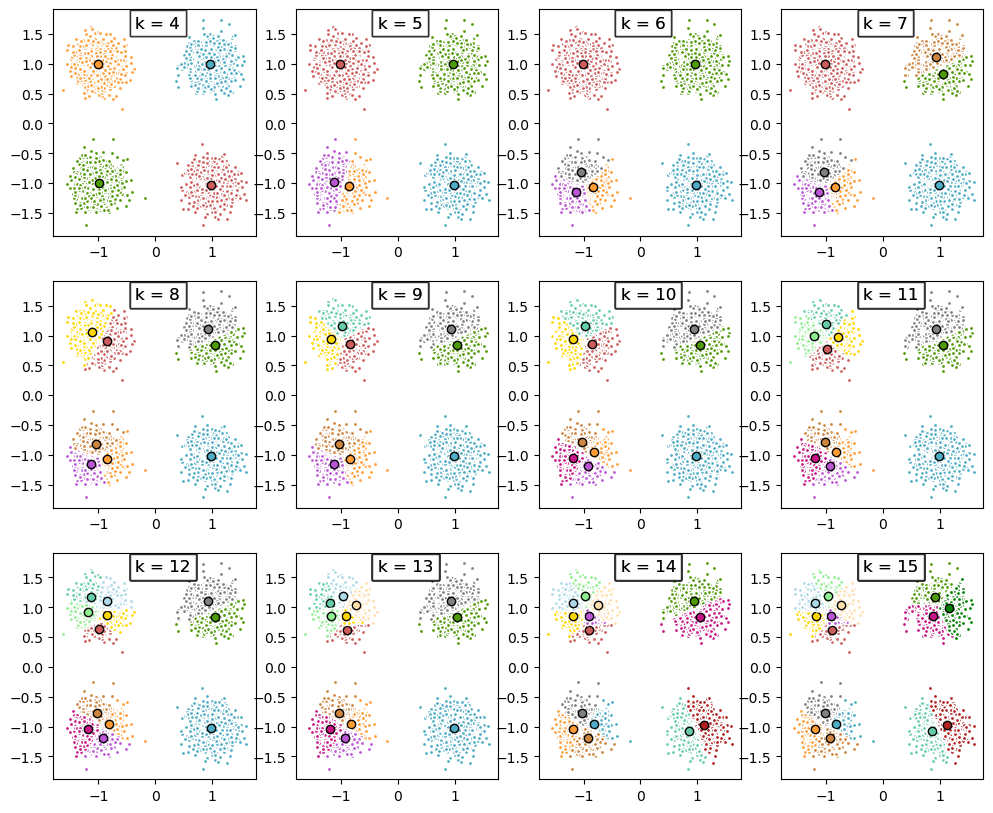

In [21]:
##############################################################################
# Plot result
fig, axs = pl.subplots(3, 4, figsize=(12, 10))
colors = ['#4EACC5', '#FF9C34', '#4E9A06', 'indianred', 'mediumorchid','grey', 'peru', 'gold', 'mediumaquamarine', 'mediumvioletred',
          'lightgreen', 'lightblue', 'navajowhite', 'firebrick', 'green', 'purple', 'darkgreen']

# KMedoids
plt_range = 12

for n_selected in range(0,plt_range):
    ax_n = [int(np.floor((n_selected)/4)), (n_selected)%4]

    n_selected = n_selected+3
    for k, col in zip(range(n_selected+1), colors[0:n_selected+1]):
        my_members = kmedoids_labels[n_selected-3] == k
        cluster_center = kmedoids_cluster_centers[n_selected-3][k]
        axs[ax_n[0],ax_n[1]].plot(X[my_members, 0], X[my_members, 1], 'w',
                markerfacecolor=col, marker='.')
        axs[ax_n[0],ax_n[1]].plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,
                                        markeredgecolor='k', markersize=6)
        axs[ax_n[0],ax_n[1]].text(-0.35, 1.6, 'k = {}'.format(n_selected+1), fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

        #axs[ax_n[0],ax_n[1]].set_title('k = {}'.format(n_selected+1))


if save_results is True:
    pl.savefig('figures/selected_4-15.png')

pl.show()

In [1]:
all_centers = []
all_centroids = []

for centers in kmedoids_cluster_centers:
    for center in centers:
        all_centers.append(center[0])
        all_centroids.append(center)

values, hubness = np.unique(all_centers, return_counts = True)

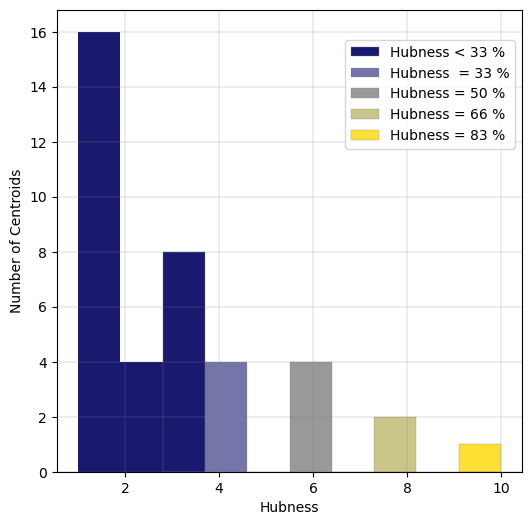

In [20]:
fig = pl.figure(figsize=(6, 6))



counts, bins = np.histogram(hubness)
N, bins, patches  = pl.hist(hubness, bins, fill = True)

for i in range(0,3):
    patches[i].set_facecolor('midnightblue')
    
patches[i].set(edgecolor = 'grey', linewidth = 0.25, label = 'Hubness < 33 %'.format(np.sum(counts[0:4])))
    
for i in range(3,5):    
    patches[i].set_facecolor('midnightblue')
    patches[i].set(edgecolor = 'grey', linewidth = 0.25)
    patches[i].set(alpha = 0.6)
patches[i].set(edgecolor = 'grey', linewidth = 0.25, label = 'Hubness  = 33 %'.format(np.sum(counts[4:9])))
    
for i in range(5, 7):
    patches[i].set_facecolor('grey')
    patches[i].set(edgecolor = 'grey', linewidth = 0.25)
    patches[i].set(alpha = 0.8)
patches[i].set(edgecolor = 'grey', linewidth = 0.25, label = 'Hubness = 50 %'.format(np.sum(counts[9:16])))
   
for i in range(7, 8):
    patches[i].set_facecolor('darkkhaki')
    patches[i].set(edgecolor = 'grey', linewidth = 0.25)
    patches[i].set(alpha = 0.8)
patches[i].set(edgecolor = 'grey', linewidth = 0.25, label = 'Hubness = 66 %'.format(np.sum(counts[16:23])))

for i in range(9, 10):
    patches[i].set_facecolor('gold')
    patches[i].set(edgecolor = 'grey', linewidth = 0.25)
    patches[i].set(alpha = 0.8)
patches[i].set(edgecolor = 'grey', linewidth = 0.25, label = 'Hubness = 83 %'.format(np.sum(counts[16:23])))

pl.grid('on', color='grey', linestyle='-', linewidth=0.2)

pl.legend(bbox_to_anchor = [1, 0.95])
pl.xlabel('Hubness')
pl.ylabel('Number of Centroids')

if save_results is True:
    pl.savefig('figure/hubness_of_sample_problem.png')

In [11]:
hubness_colors = {3:{'color':'midnightblue', 'alpha':.79},
                  4:{'color':'midnightblue', 'alpha':0.5},
                  6:{'color':'grey', 'alpha':0.8},
                  8:{'color':'darkkhaki', 'alpha':0.8},
                  10:{'color':'gold', 'alpha':0.8}}
                   
values, hubness = np.unique(all_centers, return_counts = True)

hubness_centers =  {}
centers_by_hubness = {}
for hubness_val in hubness:
    if hubness_val > 2:
        centers_by_hubness.update({hubness_val: []})
    
hub_num = 0

for x in range(len(hubness)):
    if hubness[x] > 2:
        hubness_centers.update({hub_num:{'center':all_centroids[list(all_centers).index(values[x])], 'hubness': hubness[x]}})
        centers_by_hubness[hubness[x]].append(all_centroids[list(all_centers).index(values[x])])
        hub_num+=1

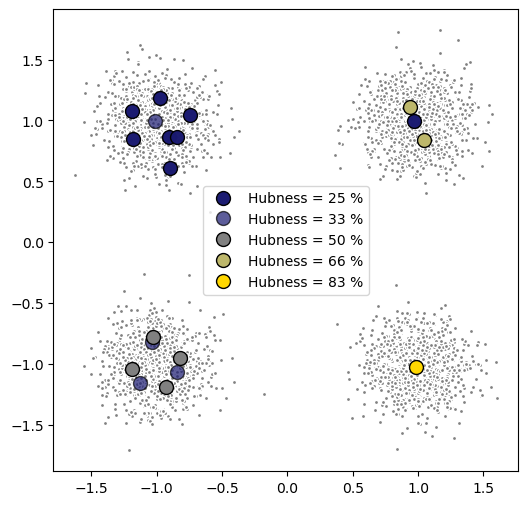

In [14]:
fig = pl.figure(figsize=(6, 6))

pl.plot(X[:, 0], X[:, 1], 'w',
                markerfacecolor='grey', marker='.')

hubness = 3

for hub in range(len(hubness_centers)):
    cluster_center = hubness_centers[hub]['center']
    if hubness_centers[hub]['hubness'] == hubness:
        pl.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=hubness_colors[hubness_centers[hub]['hubness']]['color'],
                                  markeredgecolor='k', alpha = hubness_colors[hubness_centers[hub]['hubness']]['alpha']+0.2,markersize=10,
               label = 'Hubness = {} %'.format(int(100*hubness_centers[hub]['hubness']/12)))
        if hubness == 3:
            hubness+=1
        else:
            hubness+=2
    else:
        pl.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=hubness_colors[hubness_centers[hub]['hubness']]['color'],
                                  markeredgecolor='k', alpha = hubness_colors[hubness_centers[hub]['hubness']]['alpha']+0.2,markersize=10)

pl.legend()
if save_results is True:
    pl.savefig('highest_hubness_centers_geq3.png')

pl.show()

In [224]:
def get_hubness_sets(centers_by_hubness):
    ## get sets in hubness order
    sets_of_centers_by_hubness = []
    unique_hubness = list(centers_by_hubness.keys())
    unique_hubness.sort(reverse = True)

    for n_selected in range(1,16):
        centers_hubness = []
        current_hubness = 0 
        
        while len(centers_hubness) < n_selected:
            current_centers = centers_by_hubness[unique_hubness[current_hubness]]
            if (len(centers_hubness) + len(current_centers)) <= n_selected:
                centers_hubness.extend(current_centers)
                current_hubness += 1
            else:
                n_needed = n_selected - (len(centers_hubness))
                centers_hubness.extend(random.sample(current_centers, n_needed))
                
        sets_of_centers_by_hubness.append(centers_hubness)

    return sets_of_centers_by_hubness

def get_random_sets_from_15(kmedoids_cluster_centers):
    sets_of_centers_from_15 = []

    for n_selected in range(1,16):
        sets_of_centers_from_15.append(random.sample(list(kmedoids_cluster_centers[11]), n_selected))

    return sets_of_centers_from_15
    

hubness_center_sets = get_hubness_sets(centers_by_hubness)
random_from_15_sets = get_random_sets_from_15(kmedoids_cluster_centers)
        

In [139]:
def assign_points_to_centers(cluster_centers, X):
    labels  = []
    mean_dist = 0
    for x in X:
        dist = list(euclidean_distances(cluster_centers, [x]))
        min_dist = np.min(dist)
        #print(min_dist)
        mean_dist += min_dist
        labels.append(dist.index(min_dist))
        
    return labels, mean_dist/len(X)

In [273]:
sets_labeling = {}
hubness_mean_dist = []
random_mean_dist = []
ideal_mean_dist = []
x = []

for n_selected in range(0,15):

    selected_dict = {}
    labels, mean_dist = assign_points_to_centers(hubness_center_sets[n_selected], X)
    labels = np.array(labels)
    selected_dict.update({'hubness_labels':labels, 'hubness_mean_dist': mean_dist})
    
    labels, mean_dist = assign_points_to_centers(random_from_15_sets[n_selected], X)
    labels = np.array(labels)
    selected_dict.update({'random_labels':labels, 'random_mean_dist': mean_dist})

    if n_selected >= 3:
        hubness_mean_dist.append(selected_dict['hubness_mean_dist'])
        random_mean_dist.append(selected_dict['random_mean_dist'])
        x.append(len(random_from_15_sets[n_selected]))
        
    if n_selected <= 15-4:
        _, mean_dist = assign_points_to_centers(kmedoids_cluster_centers[n_selected], X)
        selected_dict.update({'ideal_mean_dist': mean_dist})
        ideal_mean_dist.append(mean_dist)
    
    sets_labeling.update({n_selected+1: selected_dict})

0
ideal: 4
1
ideal: 5
2
ideal: 6
3
random: 4
ideal: 7
4
random: 5
ideal: 8
5
random: 6
ideal: 9
6
random: 7
ideal: 10
7
random: 8
ideal: 11
8
random: 9
ideal: 12
9
random: 10
ideal: 13
10
random: 11
ideal: 14
11
random: 12
ideal: 15
12
random: 13
13
random: 14
14
random: 15
{1: {'hubness_labels': array([0, 0, 0, ..., 0, 0, 0]), 'hubness_mean_dist': 1.7787595131223402, 'random_labels': array([0, 0, 0, ..., 0, 0, 0]), 'random_mean_dist': 1.7161659165455145, 'ideal_mean_dist': 0.251046702247195}, 2: {'hubness_labels': array([0, 1, 1, ..., 0, 0, 0]), 'hubness_mean_dist': 1.1518266610992145, 'random_labels': array([1, 1, 1, ..., 0, 1, 1]), 'random_mean_dist': 1.7693053579060778, 'ideal_mean_dist': 0.23968135722689607}, 3: {'hubness_labels': array([0, 1, 1, ..., 0, 0, 0]), 'hubness_mean_dist': 1.0989627034683378, 'random_labels': array([2, 0, 1, ..., 2, 2, 2]), 'random_mean_dist': 1.0221224350859397, 'ideal_mean_dist': 0.23045899454402582}, 4: {'hubness_labels': array([3, 1, 1, ..., 0, 3, 3]

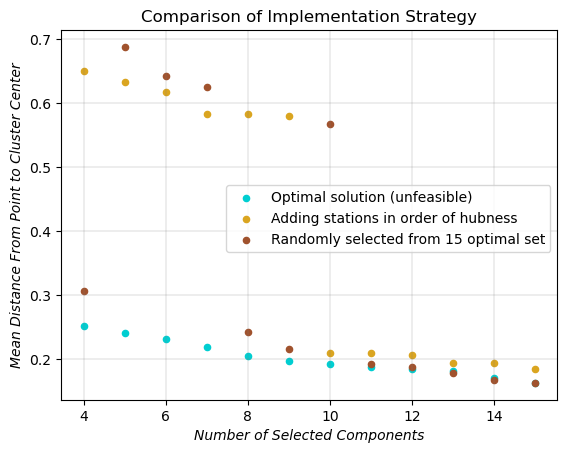

In [274]:
fig = plt.figure()

x_plot_range = [4,15]

plt.scatter(x, ideal_mean_dist, color = 'darkturquoise', label = 'Optimal solution (unfeasible)',s=20)
plt.scatter(x, hubness_mean_dist, color = 'goldenrod', label = 'Adding stations in order of hubness',s=20)
plt.scatter(x, random_mean_dist, color = 'sienna', label = 'Randomly selected from 15 optimal set',s=20)

xlab = plt.xlabel('Number of Selected Components')
ylab = plt.ylabel('Mean Distance From Point to Cluster Center')
plt.title('Comparison of Implementation Strategy');
plt.legend(bbox_to_anchor = [1, 0.6])
#plt.xlim([-5, 200])
#plt.yscale("log")

xlab.set_style('italic')
xlab.set_size(10)
ylab.set_style('italic')
ylab.set_size(10)

plt.grid('on', color='grey', linestyle='-', linewidth=0.2)

if save_results is True:
    plt.savefig('figures/abstract_example_hubness.png')
